Image Compressor

Lendo imagens

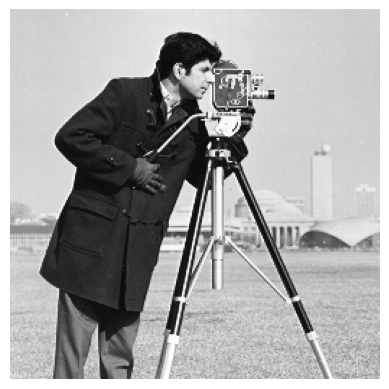

In [71]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import heapq
import numpy as np

IMAGES = ['cameraman.pgm', 'baboon.pgm', 'lena.pgm', 'unequal.pmg']
def getImageName(idx):
    return './images/' + IMAGES[idx]


img = mpimg.imread(getImageName(0))
height, width = img.shape
plt.imshow(img, cmap="gray")
plt.axis('off')
plt.show()

In [75]:
def getHistogramMap(img):
    quantidades = dict();
    for row in img:
        for el in row:
            if el in quantidades:
                quantidades[el] += 1     
            else:
                quantidades[el] = 1 

    return quantidades

def huffman(hist):
    queue = [(val, [key]) for (key, val) in hist.items()] 
    heapq.heapify(queue)

    huff_dict = {key : "" for key in hist.keys()}
    
    while len(queue) >= 2:
        val_fr, keys_fr = heapq.heappop(queue)
        val_sn, keys_sn = heapq.heappop(queue)
        nval = val_fr+val_sn
        heapq.heappush(queue, (nval, keys_fr+keys_sn))
        for k in keys_fr:
            huff_dict[k] += '0'
        for k in keys_sn:
            huff_dict[k] += '1'
        
    return {key : val[::-1] for (key, val) in huff_dict.items()} 

def encodeImage(img, huff_dict):
    return "".join(huff_dict[px] for row in img for px in row)


def decodeImage(code, huff_dict, width): 
    class node:
        def __init__(self, end=-1):
            self.to = [-1, -1]
            self.end = end
    
    tree = [node()] 
    for key, val in huff_dict.items():
        cur = tree[0];
        for ch in val:
            idx = int(ch)-int('0')
            if cur.to[idx] == -1:
                tree.append(node())
                cur.to[idx] = tree[-1]

            cur = cur.to[idx]
        cur.end = key

    img = []
    cur = tree[0]
    for ch in code:
        idx = int(ch) - int('0')
        cur = cur.to[idx]
        if cur.end != -1:
            img.append(cur.end)
            cur = tree[0]
            
    img = np.array(img)
    return img.reshape(len(img)//width, width)

hist = getHistogramMap(img)
huff_dict = huffman(hist)
encoding = encodeImage(img, huff_dict)
decoding = decodeImage(encoding, huff_dict, width)

In [83]:
def MSE(first, second):
    assert(first.shape == second.shape)
    height, width = first.shape
    
    sum = 0
    for i in range(height):
        for j in range(width):
            sum += (first[i][j]-second[i][j])**2
    return sum

def PSNR(first, second, maxPixelVal=255):
    msr = MSE(first,second)
    if msr == 0: return 50
    return 10 * np.log(maxPixelVal**2/msr)

err = MSE(img, decoding)
psnr = PSNR(img, decoding)
err, psnr

(np.uint8(0), 50)

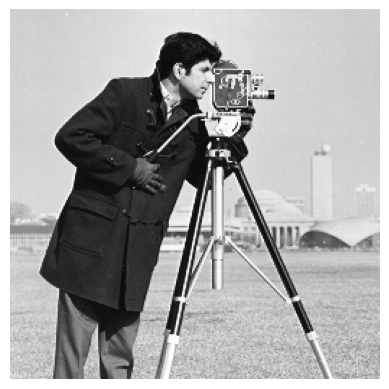

In [82]:
plt.imshow(decoding, cmap="gray")
plt.axis('off')
plt.show()

In [99]:
def entropy(hist):
    tot = width * height
    sum = 0
    for _, val in hist.items(): sum += (val/tot) * np.log2(val/tot)
    return -sum

def meanSizeHuffman(hist, dict_huff):
    tot = width * height
    sum = 0
    for key, val in hist.items(): 
        qtd_bits = len(dict_huff[key])
        sum += (val/tot) * qtd_bits
    return sum
    
init_size = 8 * height * width
encode_size = len(encoding)
entropy = entropy(hist)
mean_size_huffman = meanSizeHuffman(hist, huff_dict)
eficiency = entropy/mean_size_huffman


init_size, encode_size, eficiency

(524288, 454324, np.float64(0.9959861768809851))